In [41]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [42]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
# split data set for better visualization
df0 = df[:50]
df1 = df[50:100]
df2 = df[100:150]

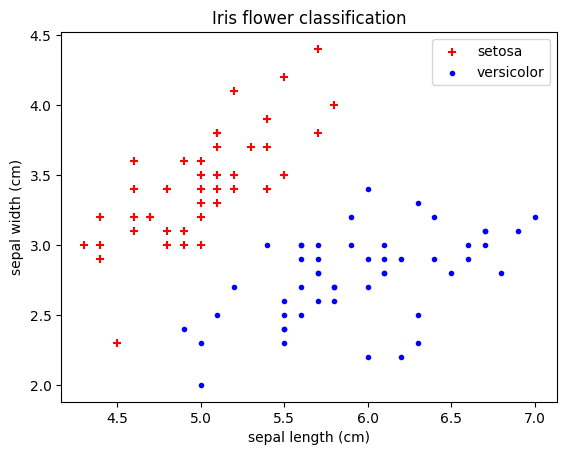

In [44]:
# Plot original data with actual labels
import matplotlib.pyplot as plt
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='red',marker='+', label='setosa')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue',marker='.', label='versicolor')
plt.legend()
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title("Iris flower classification")
plt.show()

In [45]:
X = df.drop('target', axis='columns')
y = df.target

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

In [47]:
len(X_train)

105

In [48]:
#Apply Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3)
model

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [49]:
# train and test
model.fit(X_train, y_train)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [50]:
model.n_clusters_

3

In [51]:
model.fit_predict(X_test)

array([0, 1, 0, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 2, 2, 2, 2, 2, 2, 1, 0, 0,
       2, 0, 1, 1, 2, 0, 2, 0, 1, 2, 1, 1, 2, 2, 1, 1, 1, 0, 0, 1, 1, 2,
       0])

In [52]:
agg_labels = model.fit_predict(X_test)

In [53]:
from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(y_test, agg_labels)
print("Adjusted Rand Index (ARI):", round(score, 3))

Adjusted Rand Index (ARI): 0.871


In [57]:
# Use only first two features for plotting
X_test_vis = X_test.iloc[:, :2]
X_test_vis.head()

,sepal length (cm),sepal width (cm)
115,6.4,3.2
14,5.8,4.0
136,6.3,3.4
59,5.2,2.7
38,4.4,3.0


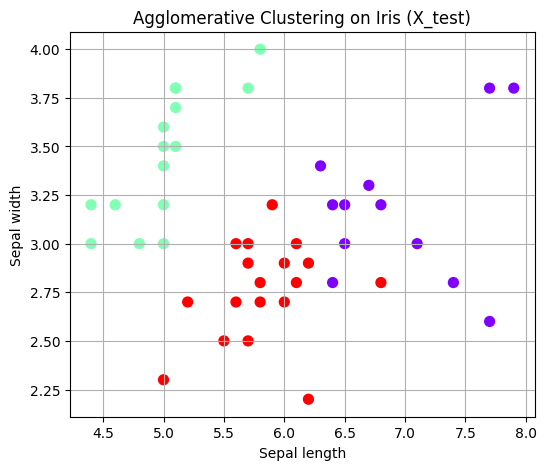

In [62]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test_vis.iloc[:, 0], X_test_vis.iloc[:, 1], c=agg_labels, cmap='rainbow', s=50)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Agglomerative Clustering on Iris (X_test)')
plt.grid(True)
plt.show()

In [ ]:
#Apply Agglomerative Clustering